# Monte Carlo simulation-based model

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
%load_ext autoreload
%autoreload 2
import Methods as m

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def visualize_rays(source_x, slit_width_W, ux, uz, z_gap_1, z_gap_2):
    Z_gate_start, Z_gate_end = 20.0, 35.0
    Rscint = 35
    Z_scint = 70
    X_gate_left, X_gate_right = -slit_width_W / 2.0, slit_width_W / 2.0

    # Classification Masks
    mask_gap = ((z_gap_2 > Z_gate_end) & (z_gap_1 < 0)) | ((z_gap_2 > Z_gate_end) & (z_gap_1 < Z_gate_start))
    # ^ Through the gap
    mask_full = (z_gap_2 < 0) | (z_gap_1 > Z_gate_end) | ((z_gap_1 < Z_gate_start) & (z_gap_1 > 0) & (z_gap_2 < 0)) | ((z_gap_1 < Z_gate_start) & (z_gap_2 < Z_gate_start) & (z_gap_1 > 0)) | (z_gap_2 < Z_gate_start) & (z_gap_1 < 0) & (z_gap_2 > 0)
    # ^ Entirely through lead (Front-to-Back)
    mask_side = ((z_gap_1 > Z_gate_start) & (z_gap_1 < Z_gate_end)) | ((z_gap_2 > Z_gate_start) & (z_gap_2 < Z_gate_end))
    # ^ mask for all rays that enter/exit at least one inside edge of a gate
    mask_both = (z_gap_1 > Z_gate_start) & (z_gap_2 < Z_gate_end)
    # ^mask for rays that enter and exit both gates

    # Plotting Gate Boundaries
    types = [
        (mask_gap, 'green', 'Air (Slit)'),
        (mask_full, 'red', 'Full Lead (Front-Back)'),
        (mask_side & ~mask_both, 'orange', 'Side Wall/Corner Clip'),
        (mask_both, 'purple', 'Both Gates')
    ]

    for mask, color, label in types:
        idx = np.where(mask)[0][:100]
        for i in idx:
            z_vals = np.array([0, Z_scint])
            x_vals = source_x + (z_vals / uz[i]) * ux[i]
            plt.plot(x_vals, z_vals, color=color, alpha=0.4, linewidth=0.8)
        plt.plot([], [], color=color, label=label)

    plt.axhspan(Z_gate_start, Z_gate_end, xmin=0, xmax=0.5 + X_gate_left/80, color='gray', alpha=0.3,zorder=3)
    plt.axhspan(Z_gate_start, Z_gate_end, xmin=0.5 + X_gate_right/80, xmax=1, color='gray', alpha=0.3,zorder=3)
    plt.axhspan(ymin=Z_scint-1, ymax=Z_scint, xmin=0.5-Rscint/80, xmax=0.5+Rscint/80, color='black', alpha=0.7,zorder=3)

    plt.title(f"X-Z Projection of Rays (Source at x={source_x})")
    plt.xlabel("X Position (mm)")
    plt.ylabel("Z Depth (mm)")
    plt.xlim(-40, 40)
    plt.ylim(0, 100)
    plt.legend(loc='upper right')
    plt.savefig("./figures/VisualizedRays", dpi=300)
    plt.show()

def visualize_mirrored_rays(source_x, slit_width_W, ux, uz, z_gap_1, z_gap_2):
    Z_gate_start, Z_gate_end = -36.0, -46.0
    Rscint = 35
    Z_scint = -70
    X_gate_left, X_gate_right = -slit_width_W / 2.0, slit_width_W / 2.0

    # Classification Masks
    mask_gap = (z_gap_2 < Z_gate_end) & (z_gap_1 > Z_gate_start)
    # ^ Through the gap
    mask_full = (z_gap_2 > 0) | (z_gap_1 < Z_gate_end) | ((z_gap_1 > Z_gate_start) & (z_gap_1 < 0) & (z_gap_2 > 0)) | ((z_gap_1 > Z_gate_start) & (z_gap_2 > Z_gate_start) & (z_gap_1 < 0)) | (z_gap_2 > Z_gate_start) & (z_gap_1 > 0) & (z_gap_2 < 0)
    # ^ Entirely through lead (Front-to-Back)
    mask_side = ((z_gap_1 < Z_gate_start) & (z_gap_1 > Z_gate_end)) | ((z_gap_2 < Z_gate_start) & (z_gap_2 > Z_gate_end))
    # ^ mask for all rays that enter/exit at least one inside edge of a gate
    mask_both = (z_gap_1 < Z_gate_start) & (z_gap_2 > Z_gate_end)
    # ^mask for rays that enter and exit both gates

    # Plotting Gate Boundaries
    types = [
        (mask_gap, 'green', 'Air (Slit)'),
        (mask_full, 'red', 'Full Lead (Front-Back)'),
        (mask_side & ~mask_both, 'orange', 'Side Wall/Corner Clip'),
        (mask_both, 'purple', 'Both Gates')]

    for mask, color, label in types:
        idx = np.where(mask)[0][:100]
        for i in idx:
            z_vals = np.array([0, Z_scint])
            x_vals = source_x + (z_vals / uz[i]) * ux[i]
            plt.plot(x_vals, z_vals, color=color, alpha=0.4, linewidth=0.8)
        plt.plot([], [], color=color, label=label)

    plt.axhspan(Z_gate_start, Z_gate_end, xmin=0, xmax=0.5 + X_gate_left/80, color='gray', alpha=0.3,zorder=3)
    plt.axhspan(Z_gate_start, Z_gate_end, xmin=0.5 + X_gate_right/80, xmax=1, color='gray', alpha=0.3,zorder=3)
    plt.axhspan(ymin=Z_scint, ymax=Z_scint + 1, xmin=0.5-Rscint/80, xmax=0.5+Rscint/80, color='black', alpha=0.7,zorder=3)

    plt.title(f"X-Z Projection of Rays (Source at x={source_x})")
    plt.xlabel("X Position (mm)")
    plt.ylabel("Z Depth (mm)")
    plt.xlim(-40, 40)
    plt.ylim(-100, 0)
    plt.legend(loc='upper right')
    plt.savefig("./figures/VisualizeMirroredRays", dpi=300)
    plt.show()

def visualize_both_rays(source_x, slit_width_W, ux, uz, z_gap_1, z_gap_2, z_gap_1_mirrored, z_gap_2_mirrored, numRays):
    Z_gate_start, Z_gate_end = 20.0, 35.0
    Rscint = 35
    Z_scint = 70
    X_gate_left, X_gate_right = -slit_width_W / 2.0, slit_width_W / 2.0

    plt.axhspan(Z_gate_start, Z_gate_end, xmin=0, xmax=0.5 + X_gate_left/80, color='gray', alpha=0.3,zorder=3)
    plt.axhspan(Z_gate_start, Z_gate_end, xmin=0.5 + X_gate_right/80, xmax=1, color='gray', alpha=0.3,zorder=3)
    plt.axhspan(ymin=Z_scint-1, ymax=Z_scint, xmin=0.5-Rscint/80, xmax=0.5+Rscint/80, color='black', alpha=0.7,zorder=3)

    """Now get bottom intersection"""

    Z_gate_start, Z_gate_end = -20.0, -35.0
    Rscint = 35
    Z_scint = -70

    plt.axhspan(Z_gate_start, Z_gate_end, xmin=0, xmax=0.5 + X_gate_left/80, color='gray', alpha=0.3,zorder=3)
    plt.axhspan(Z_gate_start, Z_gate_end, xmin=0.5 + X_gate_right/80, xmax=1, color='gray', alpha=0.3,zorder=3)
    plt.axhspan(ymin=Z_scint, ymax=Z_scint + 1, xmin=0.5-Rscint/80, xmax=0.5+Rscint/80, color='black', alpha=0.7,zorder=3)


    for i,uzVal in enumerate(uz[:numRays]):
        z_vals = np.array([0, -Z_scint])
        x_vals = source_x - (z_vals / uzVal) * ux[i]
        plt.plot(x_vals, z_vals, alpha=0.4, linewidth=0.8, color="red")

        z_vals = np.array([0, Z_scint])
        x_vals = source_x - (z_vals / uzVal) * ux[i]
        plt.plot(x_vals, z_vals, alpha=0.4, linewidth=0.8, color="blue")

    plt.title(f"X-Z Projection of Rays (Source at x={source_x})")
    plt.xlabel("X Position (mm)")
    plt.ylabel("Z Depth (mm)")
    plt.xlim(-40, 40)
    plt.ylim(-100, 100)
    # plt.legend()
    plt.savefig("./figures/VisualizeBothRays", dpi=300)
    plt.show()

In [58]:
def get_transmission_efficiency(source_x, slit_width_W, attenuation_len, n_rays=100000, R_scint=35):
    # --- Constants ---
    Z_gate_start = 20.0
    Z_gate_end = 35.0
    Z_scint = 70
    X_gate_left = -slit_width_W / 2.0
    X_gate_right = slit_width_W / 2.0
    source_x = np.where(((source_x == X_gate_left) | (source_x == X_gate_right)),source_x - 0.00001, source_x)
    np.random.seed(0)

    phi = np.random.uniform(0, 2*np.pi, n_rays)
    costheta = np.random.uniform(0, 1, n_rays)
    sintheta = np.sqrt(1 - costheta**2)

    ux = np.sin(phi) * costheta
    uy = np.sin(phi) * sintheta
    uz = np.cos(phi)
    tanphi = np.tan(phi)

    x_at_scint = source_x + Z_scint * tanphi * costheta
    y_at_scint = Z_scint * tanphi * sintheta
    x_at_scintMirrored = source_x - Z_scint * tanphi * costheta
    y_at_scintMirrored = - Z_scint * tanphi * sintheta

    hit_mask = ((x_at_scint**2 + y_at_scint**2) <= R_scint**2) & ((x_at_scintMirrored**2 + y_at_scintMirrored**2) <= R_scint**2)

    ux, uy, uz = ux[hit_mask], uy[hit_mask], uz[hit_mask]
    if len(uz) == 0: return 0.0

    z_cross_left  = (X_gate_left - source_x) * uz / ux
    z_cross_right = (X_gate_right - source_x) * uz / ux
    z_gap_1 = np.minimum(z_cross_left, z_cross_right)
    z_gap_2 = np.maximum(z_cross_left, z_cross_right)

    mask_full = (z_gap_2 < 0) | (z_gap_1 > Z_gate_end) | ((z_gap_1 < Z_gate_start) & (z_gap_1 > 0) & (z_gap_2 < 0)) | ((z_gap_1 < Z_gate_start) & (z_gap_2 < Z_gate_start) & (z_gap_1 > 0)) | (z_gap_2 < Z_gate_start) & (z_gap_1 < 0) & (z_gap_2 > 0)
    # ^ Entirely through lead (Front-to-Back)
    mask_side = ((z_gap_1 > Z_gate_start) & (z_gap_1 < Z_gate_end)) | ((z_gap_2 > Z_gate_start) & (z_gap_2 < Z_gate_end))
    # ^ mask for all rays that enter/exit at least one inside edge of a gate
    mask_both = (z_gap_1 > Z_gate_start) & (z_gap_2 < Z_gate_end)
    # ^mask for rays that enter and exit both gates

    air_start = np.maximum(z_gap_1, Z_gate_start)
    air_end   = np.minimum(z_gap_2, Z_gate_end)
    z_air_thick = np.maximum(0, air_end - air_start)

    d_lead = np.zeros_like(uz)
    d_lead = np.where(mask_full,(Z_gate_end - Z_gate_start)/np.abs(uz), d_lead)
    d_lead = np.where(mask_side | mask_both,(Z_gate_end - Z_gate_start - z_air_thick)/np.abs(uz), d_lead)

    weights = np.exp(-d_lead / attenuation_len)

    """Now I calculate the weights for the rays going in the opposite direction"""
    
    Z_gate_start = -20.0
    Z_gate_end = -35.0

    z_gap_1_mirrored = np.maximum(z_cross_left, z_cross_right)
    z_gap_2_mirrored = np.minimum(z_cross_left, z_cross_right)

    mask_full = (z_gap_2_mirrored > 0) | (z_gap_1_mirrored < Z_gate_end) | ((z_gap_1_mirrored > Z_gate_start) & (z_gap_1_mirrored < 0) & (z_gap_2_mirrored > 0)) | ((z_gap_1_mirrored > Z_gate_start) & (z_gap_2_mirrored > Z_gate_start) & (z_gap_1_mirrored < 0)) | (z_gap_2_mirrored > Z_gate_start) & (z_gap_1_mirrored > 0) & (z_gap_2_mirrored < 0)
    # ^ Entirely through lead (Front-to-Back)
    mask_side = ((z_gap_1_mirrored < Z_gate_start) & (z_gap_1_mirrored > Z_gate_end)) | ((z_gap_2_mirrored < Z_gate_start) & (z_gap_2_mirrored > Z_gate_end))
    # ^ mask for all rays that enter/exit at least one inside edge of a gate
    mask_both = (z_gap_1_mirrored < Z_gate_start) & (z_gap_2_mirrored > Z_gate_end)
    # ^mask for rays that enter and exit both gates

    air_start = np.maximum(z_gap_1_mirrored, Z_gate_start)
    air_end   = np.minimum(z_gap_2_mirrored, Z_gate_end)
    z_air_thick = np.maximum(0, air_end - air_start)
    d_lead = np.zeros_like(uz)
    d_lead = np.where(mask_full,(Z_gate_start - Z_gate_end)/np.abs(uz), d_lead)
    d_lead = np.where(mask_side | mask_both,(Z_gate_start - Z_gate_end - z_air_thick)/np.abs(uz), d_lead)

    weights_reversed = np.exp(-d_lead / attenuation_len)

    normalizedWeight = np.sum(weights * weights_reversed) / n_rays

    return normalizedWeight

In [4]:
get_transmission_efficiency(1.01,slit_width_W=2,attenuation_len=5.6,n_rays=50, R_scint=35)

0.007194901628442761

In [5]:
x_scan = np.arange(-10, 10, 0.01)
transmission = []
Rscint = 35 # mm

for x in x_scan:
    val = get_transmission_efficiency(x, slit_width_W=2.0, attenuation_len=5.6, n_rays=10000, R_scint=Rscint)
    transmission.append(val)


In [6]:
A = 0.15
Rsource = 1.1
x0 = 0
distanceStep = x_scan[1] - x_scan[0]
background = 0.00611 # times exposure time


Signal_Modelled = A*np.array(transmission) * 60

Xsource = np.arange(start=-Rsource + x0,stop=Rsource + x0,step=distanceStep)
sourceArr = m.sphereConvolve(Rsource, Xsource, x0)

convolvedSignal = np.convolve(Signal_Modelled, sourceArr, mode='full')
convolvedX = np.arange(start=-len(convolvedSignal)/2, stop=len(convolvedSignal)/2, step=1) * distanceStep + x0
convolvedSignal = convolvedSignal + background * 60 #+ background

convolvedSignal = np.roll(convolvedSignal,-10)

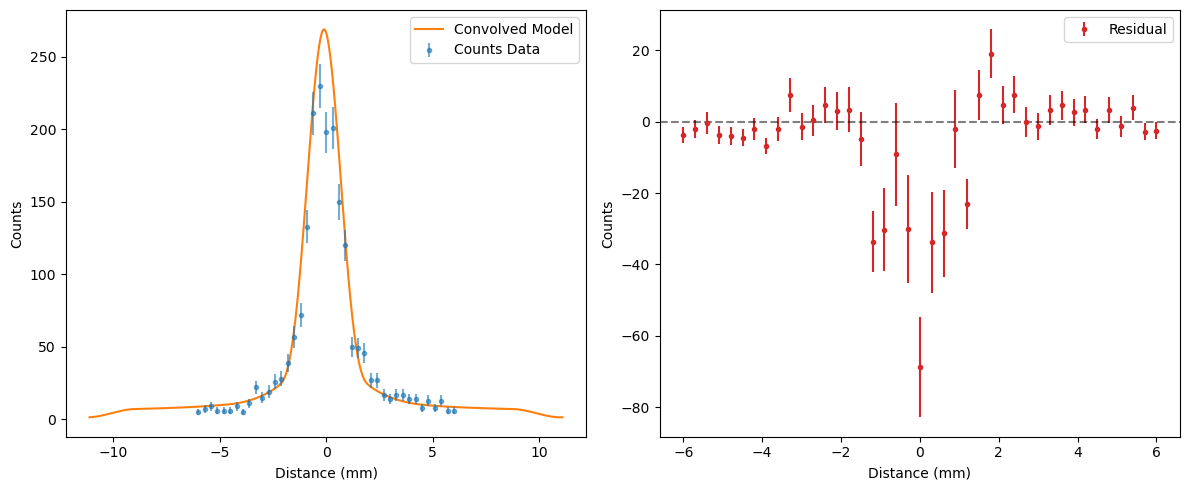

In [7]:
dist_array, counts_array, ucounts_array = m.readLineScan("./data/Lead Linescans - Feb 4/Feb 4, 2026, 3_25 PM, Scan1, 0_0 Deg, w-2mm.dat")

m.displayModelDataLinescan(convolvedX, convolvedSignal, dist_array, counts_array, ucounts_array, "MonteCarlo Model+Residual - 2mm lead linescan.png")

### Fitting 5mm linescan

In [8]:
x_scan = np.arange(-10, 10, 0.01)
transmission = []
Wslit = 5

for x in x_scan:
    val = get_transmission_efficiency(x, slit_width_W=Wslit, attenuation_len=5.6, n_rays=20000)
    transmission.append(val)


In [9]:
A = 0.15
Rscint = 35 # mm
Rsource = 1.1
x0 = 0
distanceStep = x_scan[1] - x_scan[0]
background = 0.00611 # times exposure time

Signal_Modelled = A*np.array(transmission) * 30

Xsource = np.arange(start=-Rsource + x0,stop=Rsource + x0,step=distanceStep)
scintArr = m.circleConvolve(Rscint, x_scan, x0)
sourceArr = m.sphereConvolve(Rsource, Xsource, x0)

convolvedSignal = np.convolve(Signal_Modelled, sourceArr, mode='full')
convolvedX = np.arange(start=-len(convolvedSignal)/2, stop=len(convolvedSignal)/2, step=1) * distanceStep + x0
convolvedSignal = convolvedSignal + background * 30 #+ background #+ background

convolvedSignal = convolvedSignal # * max(Signal_Modelled) / max(convolvedSignal)
convolvedSignal = np.roll(convolvedSignal,-75)

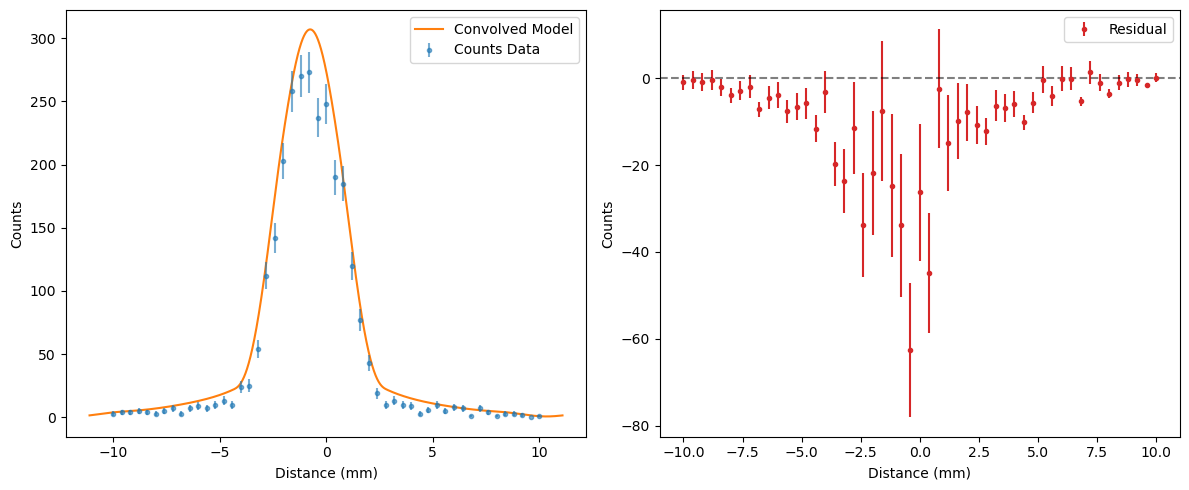

In [10]:
dist_array, counts_array, ucounts_array = m.readLineScan("./data/Lead Linescans - Feb 4/Feb 4, 2026, 2_37 PM, Scan1, 0_0 Deg, w-5mm.dat")

m.displayModelDataLinescan(convolvedX, convolvedSignal, dist_array, counts_array, ucounts_array, "MonteCarlo Model+Residual - 5mm lead linescan.png")

### Fitting 1mm linescan

In [11]:
x_scan = np.arange(-10, 10, 0.01)
transmission = []
Wslit = 1

for x in x_scan:
    val = get_transmission_efficiency(x, slit_width_W=Wslit, attenuation_len=5.6, n_rays=20000)
    transmission.append(val)


In [12]:
A = 0.15
Rscint = 35 # mm
Rsource = 1.1
x0 = 0
distanceStep = x_scan[1] - x_scan[0]
background = 0.00611 # times exposure time

Signal_Modelled = A*np.array(transmission) * 120

Xsource = np.arange(start=-Rsource + x0,stop=Rsource + x0,step=distanceStep)
scintArr = m.circleConvolve(Rscint, x_scan, x0)
sourceArr = m.sphereConvolve(Rsource, Xsource, x0)

convolvedSignal = np.convolve(Signal_Modelled, sourceArr, mode='full')
convolvedX = np.arange(start=-len(convolvedSignal)/2, stop=len(convolvedSignal)/2, step=1) * distanceStep + x0
convolvedSignal = convolvedSignal + background * 120 #+ background

convolvedSignal = np.roll(convolvedSignal,-40)

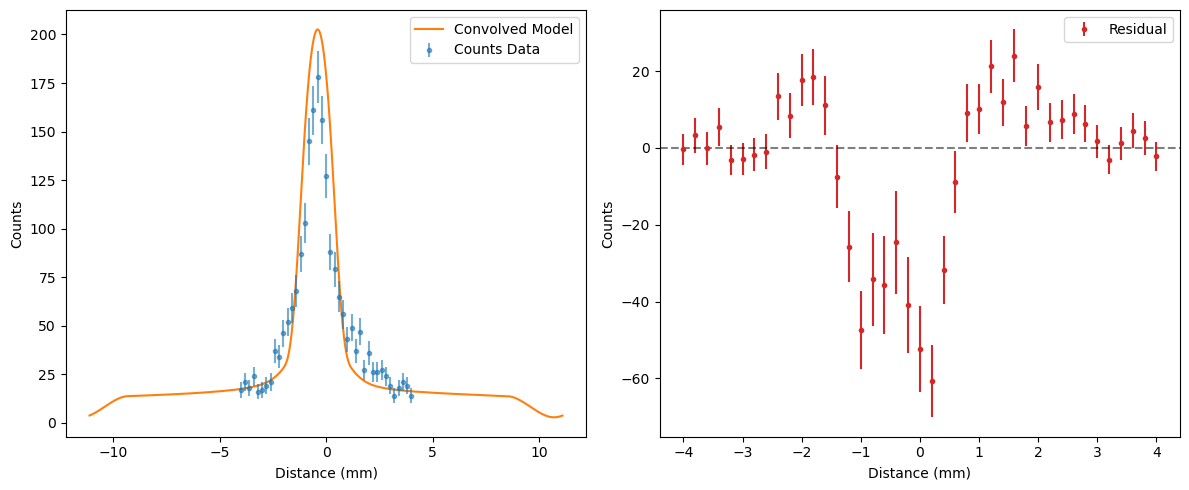

In [13]:
dist_array, counts_array, ucounts_array = m.readLineScan("./data/Lead Linescans - Feb 4/Feb 4, 2026, 5_01 PM, Scan1, 0_0 Deg, w-1mm.dat")

m.displayModelDataLinescan(convolvedX, convolvedSignal, dist_array, counts_array, ucounts_array, "MonteCarlo Model+Residual - 1mm lead linescan.png")

### Trying larger stepsize and smaller numCounts

In [14]:
x_scan = np.arange(-10, 10, 0.5)
transmission = []
Wslit = 5

for x in x_scan:
    val = get_transmission_efficiency(x, slit_width_W=Wslit, attenuation_len=5.6, n_rays=5000)
    transmission.append(val)


In [15]:
distanceStep = x_scan[1] - x_scan[0]
A = 15 * distanceStep
Rscint = 35 # mm
Rsource = 1.1
x0 = -0.9
background = 0.00611 # times exposure time

Signal_Modelled = A*np.array(transmission) * 30

Xsource = np.arange(start=-Rsource + x0,stop=Rsource + x0,step=distanceStep)
scintArr = m.circleConvolve(Rscint, x_scan, x0)
sourceArr = m.sphereConvolve(Rsource, Xsource, x0)

convolvedSignal = np.convolve(Signal_Modelled, sourceArr, mode='full')
convolvedX = np.arange(start=-len(convolvedSignal)/2, stop=len(convolvedSignal)/2, step=1) * distanceStep + x0
convolvedSignal = convolvedSignal + background * 30 #+ background #+ background

convolvedSignal = convolvedSignal # * max(Signal_Modelled) / max(convolvedSignal)
# convolvedSignal = np.roll(convolvedSignal,-75)

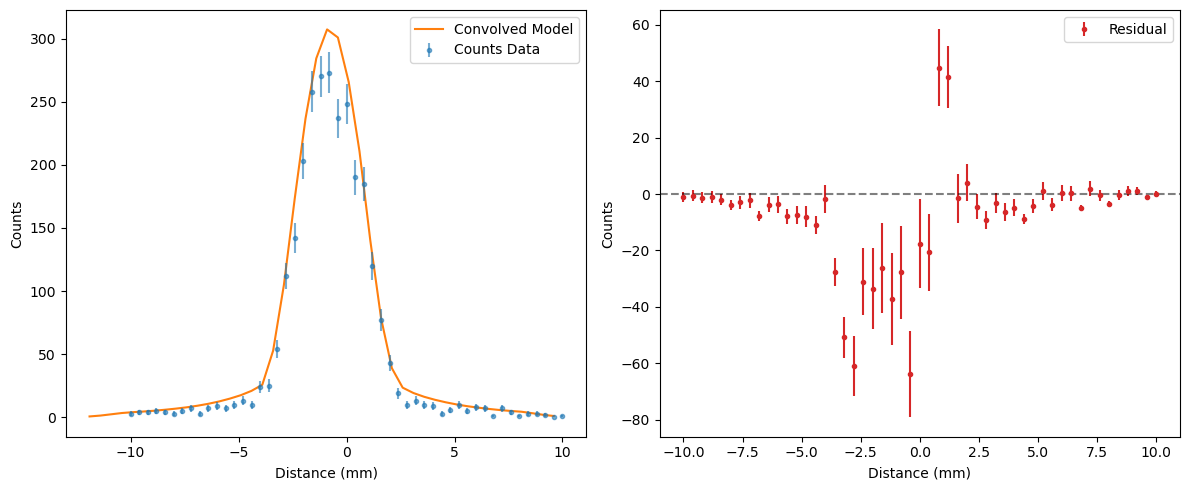

In [16]:
dist_array, counts_array, ucounts_array = m.readLineScan("./data/Lead Linescans - Feb 4/Feb 4, 2026, 2_37 PM, Scan1, 0_0 Deg, w-5mm.dat")

m.displayModelDataLinescan(convolvedX, convolvedSignal, dist_array, counts_array, ucounts_array, "shitty fitting.png")

## Making Model Callable

In [17]:
def monte_carlo_model(source_x_arr, x0, slitW, attenuation_len, A, source_R, exposure_time, background):
    distanceStep = source_x_arr[1] - source_x_arr[0]
    A = A * distanceStep
    # x_scan = source_x_arr[0]
    transmission = []

    for x in source_x_arr:
        val = get_transmission_efficiency(x-x0, slit_width_W=slitW, attenuation_len=attenuation_len, n_rays=50000, R_scint=35)
        transmission.append(val)

    # background = 0.00611 # times exposure time

    Signal_Modelled = A*np.array(transmission) * exposure_time

    Xsource = np.arange(start=-source_R,stop=source_R,step=distanceStep)
    sourceArr = m.sphereConvolve(source_R, Xsource, 0)

    convolvedSignal = np.convolve(Signal_Modelled, sourceArr, mode='full')
    convolvedSignal = convolvedSignal + background * exposure_time #+ background


    if (len(convolvedSignal) < len(source_x_arr)):
        convolvedSignal = np.pad(convolvedSignal, np.round((len(source_x_arr) - len(convolvedSignal))/2).astype(int), mode='constant' ,constant_values=background)
    elif (len(convolvedSignal) > len(source_x_arr)):
        convolvedSignal = convolvedSignal[len(convolvedSignal)//2-len(source_x_arr)//2:len(convolvedSignal)//2 + len(source_x_arr)//2]
    # May need to do additional checks of inequality (in case of off-by-1 error)

    if (len(convolvedSignal) < len(source_x_arr)):
        convolvedSignal = np.append(convolvedSignal, convolvedSignal[-1])
    elif (len(convolvedSignal) > len(source_x_arr)):
        convolvedSignal = np.delete(convolvedSignal, -1)

    return convolvedSignal

### Autofitting 5mm slit width

In [75]:
# x_scan = np.arange(-10, 10, 0.01)
dist_array, counts_array, ucounts_array = m.readLineScan("./data/Lead Linescans - Feb 4/Feb 4, 2026, 2_37 PM, Scan1, 0_0 Deg, w-5mm.dat")

# print(ucounts_array)
mask = ucounts_array > 0
filtered_arr = ucounts_array[mask]
min_ucount = np.min(filtered_arr)

ucounts_array = np.where(ucounts_array == 0, min_ucount, ucounts_array)

# exposure_time = 30
# slitWidth = 5
# attenuation_len = 5.6
# background = 0.00611 # times exposure time


initial_guess = [15]
lower_limits = [5]
upper_limits = [20]
def monte_carlo_model_fixedVals(source_x_arr, A):
    source_R = 1.2
    slitW = 5
    attenuation_len = 5.5
    background = 0.00611
    x0 = -0.7
    exposure_time = 30
    return monte_carlo_model(source_x_arr, x0, slitW, attenuation_len, A, source_R, exposure_time, background)

popt, pcov = curve_fit(monte_carlo_model_fixedVals, dist_array, counts_array, bounds=(lower_limits, upper_limits),sigma=ucounts_array, p0=initial_guess)

In [76]:
print("Parameters:")
print(popt, np.diag(pcov))
residuals = counts_array - monte_carlo_model_fixedVals(dist_array, *popt)
chi_squared = np.sum((residuals / ucounts_array)**2)
dof = len(counts_array) - len(popt)
reduced_chi_squared = chi_squared / dof

print(f"Chi-Squared: {chi_squared:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Reduced Chi-Squared: {reduced_chi_squared:.4f}")

x_scan = np.arange(-10, 10, 0.1)
model_interpolated = monte_carlo_model_fixedVals(x_scan, *popt)

Parameters:
[9.52190238] [0.07218105]
Chi-Squared: 99.9863
Degrees of Freedom: 50
Reduced Chi-Squared: 1.9997


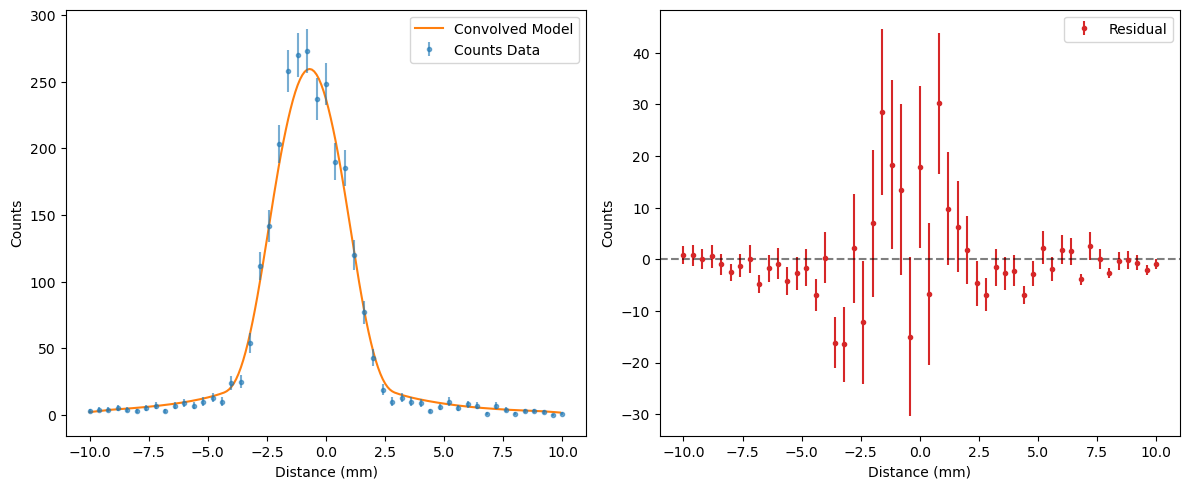

In [77]:

m.displayModelDataLinescan(x_scan, model_interpolated, dist_array, counts_array, ucounts_array, "autofitting w=5mm lead linescan.png")

### autofitting 2mm slit width

In [109]:
# x_scan = np.arange(-10, 10, 0.01)
dist_array, counts_array, ucounts_array = m.readLineScan("./data/Lead Linescans - Feb 4/Feb 4, 2026, 3_25 PM, Scan1, 0_0 Deg, w-2mm.dat")

mask = ucounts_array > 0
filtered_arr = ucounts_array[mask]
min_ucount = np.min(filtered_arr)

ucounts_array = np.where(ucounts_array == 0, min_ucount, ucounts_array)

# initial_guess = [13]
# lower_limits = [5]
# upper_limits = [20]
# def monte_carlo_model_fixedVals(source_x_arr, A):
#     source_R = 1.2
#     slitW = 2
#     attenuation_len = 5.5
#     background = 0.00611
#     x0 = 0
#     exposure_time = 60
#     return monte_carlo_model(source_x_arr, x0, slitW, attenuation_len, A, source_R, exposure_time, background)
#
# popt, pcov = curve_fit(monte_carlo_model_fixedVals, dist_array, counts_array, bounds=(lower_limits, upper_limits),sigma=ucounts_array, p0=initial_guess)


exposure_time = 60
slitWidth = 2
attenuation_len = 5.6
background = 0.00611 # times exposure time


initial_guess = [-0.1, slitWidth, attenuation_len, 15, 1.2, exposure_time, background]
lower_limits = [-0.5,  0.9*slitWidth,  0.99*attenuation_len,  5,   1.1,  exposure_time * 0.99, background*0.9]
upper_limits = [ -0.075,  1.1*slitWidth, 1.01*attenuation_len, 20, 1.3, exposure_time * 1.01, background*1.1]
#(source_x_arr, x0, slitW, attenuation_len, A, source_R, exposure_time):

popt, pcov = curve_fit(monte_carlo_model, dist_array, counts_array, bounds=(lower_limits, upper_limits),sigma=ucounts_array, p0=initial_guess)

In [110]:
print("Parameters:")
print(popt, np.diag(pcov))
residuals = counts_array - monte_carlo_model(dist_array, *popt)
chi_squared = np.sum((residuals / ucounts_array)**2)
dof = len(counts_array) - len(popt)
reduced_chi_squared = chi_squared / dof

print(f"Chi-Squared: {chi_squared:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Reduced Chi-Squared: {reduced_chi_squared:.4f}")

x_scan = np.arange(-10, 10, 0.1)
model_interpolated = monte_carlo_model(x_scan, *popt)

Parameters:
[-7.51068919e-02  1.88959089e+00  5.65381321e+00  1.10789720e+01
  1.19079229e+00  5.97713809e+01  2.45980845e-02] [2.98337220e-01 2.57556638e+00 2.83008091e-01 4.00746965e+15
 8.74753422e-02 1.16642792e+17 1.97548575e+10]
Chi-Squared: 67.4267
Degrees of Freedom: 34
Reduced Chi-Squared: 1.9831


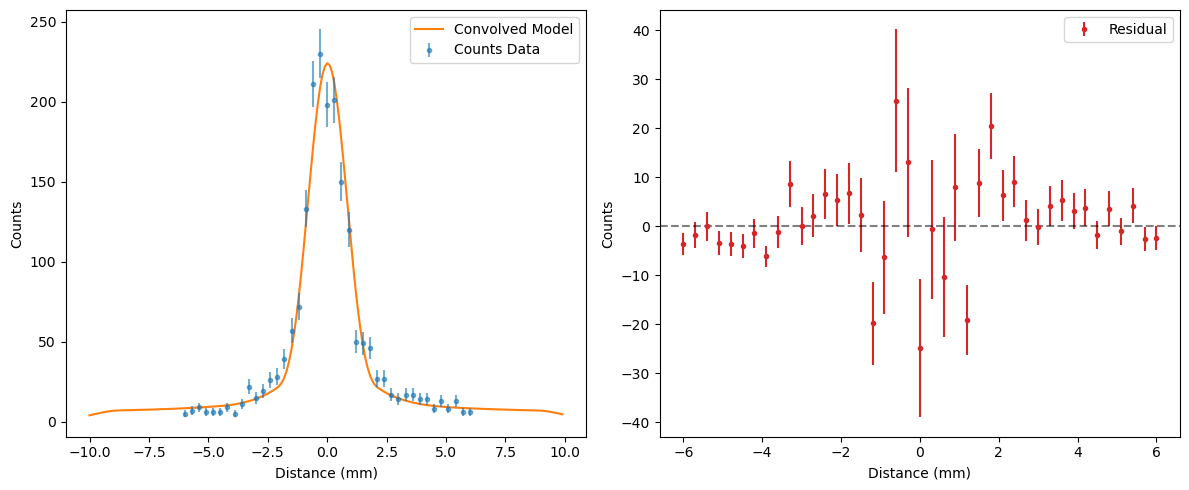

In [111]:
m.displayModelDataLinescan(x_scan, model_interpolated, dist_array, counts_array, ucounts_array, "autofitting w=2mm lead linescan.png")

### autofitting 1mm slit width

In [81]:
# x_scan = np.arange(-10, 10, 0.01)
dist_array, counts_array, ucounts_array = m.readLineScan("./data/Lead Linescans - Feb 4/Feb 4, 2026, 5_01 PM, Scan1, 0_0 Deg, w-1mm.dat")

mask = ucounts_array > 0
filtered_arr = ucounts_array[mask]
min_ucount = np.min(filtered_arr)

ucounts_array = np.where(ucounts_array == 0, min_ucount, ucounts_array)

initial_guess = [13]
lower_limits = [5]
upper_limits = [20]
def monte_carlo_model_fixedVals(source_x_arr, A):
    source_R = 1.2
    slitW = 1
    attenuation_len = 5.5
    background = 0.00611
    x0 = -0.45
    exposure_time = 120
    return monte_carlo_model(source_x_arr, x0, slitW, attenuation_len, A, source_R, exposure_time, background)

popt, pcov = curve_fit(monte_carlo_model_fixedVals, dist_array, counts_array, bounds=(lower_limits, upper_limits),sigma=ucounts_array, p0=initial_guess)
# exposure_time = 120
# slitWidth = 1
# attenuation_len = 5.6
# background = 0.00611 # times exposure time
#
#
# initial_guess = [-0.6, slitWidth, attenuation_len, 15, 1.2, exposure_time, background]
# lower_limits = [-1,  0.9*slitWidth,  0.99*attenuation_len,  5,   1.1,  exposure_time * 0.99, background*0.9]
# upper_limits = [ 0,  1.1*slitWidth, 1.01*attenuation_len, 20, 1.3, exposure_time * 1.01, background*1.1]
# #(source_x_arr, x0, slitW, attenuation_len, A, source_R, exposure_time):
#
# popt, pcov = curve_fit(monte_carlo_model, dist_array, counts_array, bounds=(lower_limits, upper_limits),sigma=ucounts_array, p0=initial_guess)

In [82]:
print("Parameters:")
print(popt, np.diag(pcov))
residuals = counts_array - monte_carlo_model_fixedVals(dist_array, *popt)
chi_squared = np.sum((residuals / ucounts_array)**2)
dof = len(counts_array) - len(popt)
reduced_chi_squared = chi_squared / dof

print(f"Chi-Squared: {chi_squared:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Reduced Chi-Squared: {reduced_chi_squared:.4f}")

x_scan = np.arange(-10, 10, 0.1)
model_interpolated = monte_carlo_model_fixedVals(x_scan, *popt)

Parameters:
[9.7251578] [0.24853389]
Chi-Squared: 182.7362
Degrees of Freedom: 40
Reduced Chi-Squared: 4.5684


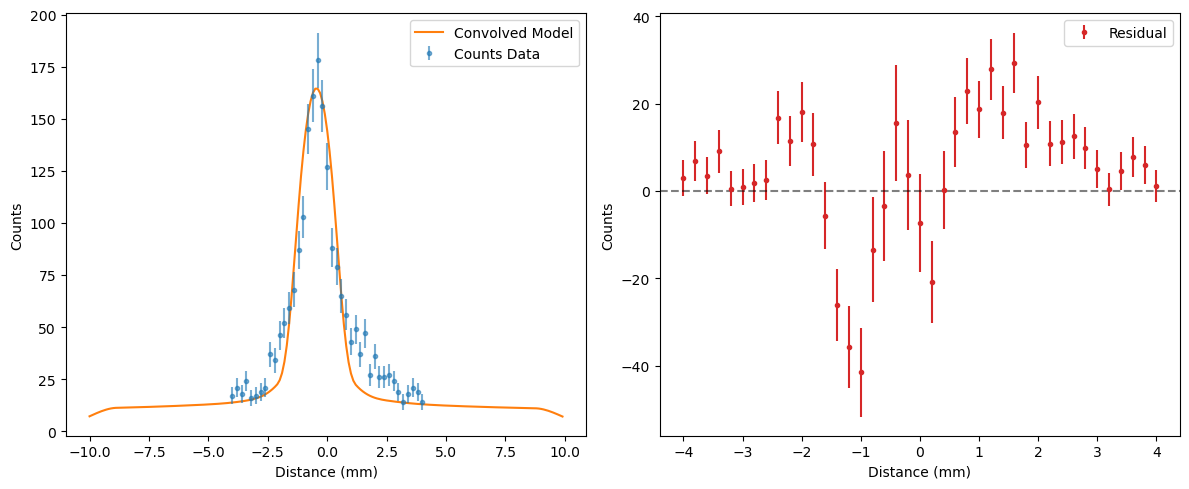

In [83]:
m.displayModelDataLinescan(x_scan, model_interpolated, dist_array, counts_array, ucounts_array, "autofitting w=1mm lead linescan.png")

### autofitting 8mm slit width

In [112]:
# x_scan = np.arange(-10, 10, 0.01)
dist_array, counts_array, ucounts_array = m.readLineScan("./data/Lead Linescans - Feb 4/Feb 13, 2026, 3_10 PM, Scan1, 0_0 Deg, w-8mm.dat")

mask = ucounts_array > 0
filtered_arr = ucounts_array[mask]
min_ucount = np.min(filtered_arr)

ucounts_array = np.where(ucounts_array == 0, min_ucount, ucounts_array)

# initial_guess = [13]
# lower_limits = [5]
# upper_limits = [20]
# def monte_carlo_model_fixedVals(source_x_arr, A):
#     source_R = 1.2
#     slitW = 8
#     attenuation_len = 5.5
#     background = 0.00611
#     x0 = -0.6
#     exposure_time = 30
#     return monte_carlo_model(source_x_arr, x0, slitW, attenuation_len, A, source_R, exposure_time, background)
#
# popt, pcov = curve_fit(monte_carlo_model_fixedVals, dist_array, counts_array, bounds=(lower_limits, upper_limits),sigma=ucounts_array, p0=initial_guess)

exposure_time = 30
slitWidth = 8
attenuation_len = 5.5
background = 0.00611 # times exposure time


initial_guess = [-0.6, slitWidth, attenuation_len, 15, 1.2, exposure_time, background]
lower_limits = [-1,  0.9*slitWidth,  0.99*attenuation_len,  5,   1.1,  exposure_time * 0.99, background*0.9]
upper_limits = [ 0,  1.1*slitWidth, 1.01*attenuation_len, 20, 1.3, exposure_time * 1.01, background*1.1]
#(source_x_arr, x0, slitW, attenuation_len, A, source_R, exposure_time):

popt, pcov = curve_fit(monte_carlo_model, dist_array, counts_array, bounds=(lower_limits, upper_limits),sigma=ucounts_array, p0=initial_guess)

In [113]:
print("Parameters:")
print(popt, np.diag(pcov))
residuals = counts_array - monte_carlo_model(dist_array, *popt)
chi_squared = np.sum((residuals / ucounts_array)**2)
dof = len(counts_array) - len(popt)
reduced_chi_squared = chi_squared / dof

print(f"Chi-Squared: {chi_squared:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Reduced Chi-Squared: {reduced_chi_squared:.4f}")

x_scan = np.arange(-10, 10, 0.1)
model_interpolated = monte_carlo_model(x_scan, *popt)

Parameters:
[-7.19716874e-01  8.18266619e+00  5.45740903e+00  1.22647058e+01
  1.24338307e+00  2.99363424e+01  6.72078392e-03] [2.14562940e-02 3.02975820e-02 1.65199626e-02 2.35850225e+14
 5.70157878e-03 1.40513970e+15 7.08209396e+07]
Chi-Squared: 136.3607
Degrees of Freedom: 114
Reduced Chi-Squared: 1.1961


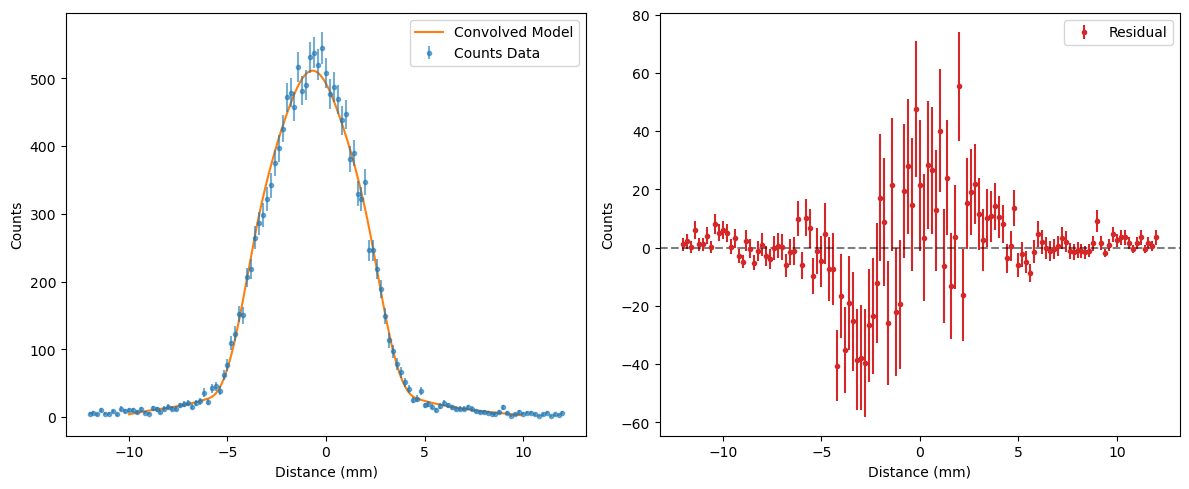

In [114]:
m.displayModelDataLinescan(x_scan, model_interpolated, dist_array, counts_array, ucounts_array, "autofitting w=8mm lead linescan.png")